# Yelp Open Dataset: three stakeholders, three questions

174,565 businesses, 16.6M check-ins, 5.26M reviews, 1.1M tips across 11 metro areas.

| Stakeholder | Question | Tables |
|---|---|---|
| Merchant | When do customers actually show up, and does it differ by business type? | check-in, business |
| Merchant | What do unhappy customers write that happy ones don't? | tip, review, business |
| Platform | Is the Elite programme selecting better reviewers? | user, review |

Every number quoted in the README is written to `outputs/results.json`.
Every figure is written to `figures/` and displayed inline.

**Data:** download the seven CSVs (see README) into `data/`, or set `YELP_DATA_DIR`.

### Running on Colab

```python
from google.colab import drive; drive.mount('/content/drive')
import os
REPO = '/content/drive/My Drive/DS_Project_Portfolio/yelp-stakeholder-analysis'
os.environ['YELP_DATA_DIR'] = REPO + '/data/'
os.environ['YELP_REPO_DIR'] = REPO          # figures/ and outputs/ land here
!pip -q install textblob
```

Run that **before** the imports cell below. The setup cell prints the absolute paths it resolved —
check them before running the rest, because a relative path in Colab resolves against `/content`,
not against the notebook. Use a High-RAM runtime: the review table with text is about 6 GB.

Figures are saved to `figures/` and also displayed inline.

In [1]:
from google.colab import drive; drive.mount('/content/drive')
import os
REPO = '/content/drive/My Drive/DS_Project_Portfolio/Yelp-analysis'
os.environ['YELP_DATA_DIR'] = REPO + '/data/'
os.environ['YELP_REPO_DIR'] = REPO          # figures/ and outputs/ land here
!pip -q install textblob

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os, re, json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

try:                                  # force inline rendering in Jupyter/Colab
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

# --- paths -------------------------------------------------------------------
# REPO_DIR is where figures/ and outputs/ get written. It defaults to the parent
# of the notebook's own directory when that looks like a repo checkout, and
# otherwise to the current directory. Override either variable directly.
DATA_DIR = os.environ.get("YELP_DATA_DIR", "../data/")
REPO_DIR = os.environ.get("YELP_REPO_DIR",
                          ".." if os.path.basename(os.getcwd()) == "notebooks" else ".")

DATA_DIR = os.path.abspath(DATA_DIR) + os.sep
FIG = os.path.abspath(os.path.join(REPO_DIR, "figures")) + os.sep
OUT = os.path.abspath(os.path.join(REPO_DIR, "outputs")) + os.sep
os.makedirs(FIG, exist_ok=True); os.makedirs(OUT, exist_ok=True)

print("reading data from :", DATA_DIR)
print("writing figures to:", FIG)
print("writing outputs to:", OUT)
print("matplotlib backend:", matplotlib.get_backend())
assert os.path.exists(DATA_DIR + "yelp_business.csv"), \
    f"yelp_business.csv not found in {DATA_DIR} — set YELP_DATA_DIR to your data folder"

# --- plotting ----------------------------------------------------------------
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 120, "savefig.bbox": "tight",
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})
DAYS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
R = {}          # every number quoted in the README lands here

def show(fig, name):
    """Save to figures/ and render inline, so the notebook is readable on GitHub."""
    fig.savefig(FIG + name)
    plt.show()
    print("saved", FIG + name)

reading data from : /content/drive/My Drive/DS_Project_Portfolio/Yelp-analysis/data/
writing figures to: /content/drive/My Drive/DS_Project_Portfolio/Yelp-analysis/figures/
writing outputs to: /content/drive/My Drive/DS_Project_Portfolio/Yelp-analysis/outputs/
matplotlib backend: module://matplotlib_inline.backend_inline


---
## 1. Load and clean

Five decisions, each of which changes an answer downstream.

| Issue | Size | Decision | Reason |
|---|---|---|---|
| `name`, `address` wrapped in literal quotes | all rows | strip `"` | CSV export artefact |
| `neighborhood` missing | 61.0% | drop the column | unusable |
| `city` is free text — 22 spellings of "Las Vegas" | — | group geography by `state` | city-level cuts silently split a metro |
| missing `city` / `latitude` | 1 row | drop | |
| closed businesses (`is_open = 0`) | 16.0% | **keep** | dropping them hides the closure pattern in §2 |

In [3]:
biz = pd.read_csv(DATA_DIR + "yelp_business.csv")
tip = pd.read_csv(DATA_DIR + "yelp_tip.csv")
chk = pd.read_csv(DATA_DIR + "yelp_checkin.csv")

R["n_business_raw"] = len(biz)
R["neighborhood_missing_pct"] = round(biz["neighborhood"].isnull().mean(), 4)
R["vegas_spellings"] = int(biz.loc[biz["city"].str.contains("vegas", case=False, na=False), "city"].nunique())

biz["name"] = biz["name"].str.strip('"')
biz = biz.dropna(subset=["city", "latitude"]).drop(columns=["neighborhood"])
biz["is_restaurant"] = biz["categories"].str.contains("Restaurants", na=False)
tip = tip.dropna(subset=["text"])

R["n_business"] = len(biz)
R["n_states"] = int(biz["state"].nunique())
R["is_open_rate"] = round(biz["is_open"].mean(), 4)
R["restaurant_share"] = round(biz["is_restaurant"].mean(), 4)
R["n_tips"] = len(tip)
R["checkin_total"] = int(chk["checkins"].sum())

print(f"{R['n_business']:,} businesses | {R['is_open_rate']:.1%} open | "
      f"{R['restaurant_share']:.1%} restaurants | {R['checkin_total']:,} check-ins | {R['n_tips']:,} tips")

174,565 businesses | 84.0% open | 31.3% restaurants | 16,648,358 check-ins | 1,098,319 tips


---
## 2. The market being described

Context for the three questions: what is on this platform, and how is attention distributed?

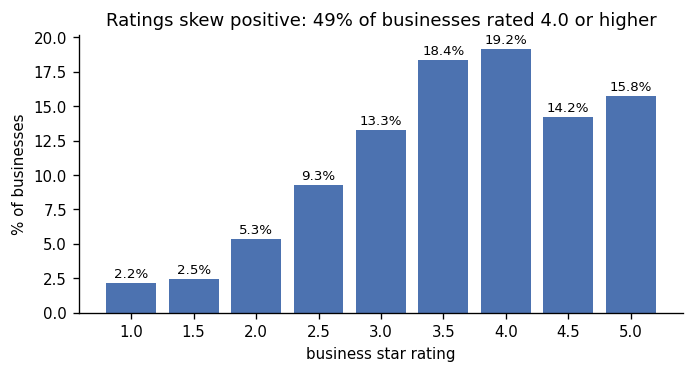

saved /content/drive/My Drive/DS_Project_Portfolio/Yelp-analysis/figures/01_star_distribution.png


In [4]:
sd = biz["stars"].value_counts(normalize=True).sort_index()
R["stars_dist"] = sd.round(4).to_dict()
R["share_4plus"] = round(float(sd.loc[4.0:].sum()), 4)

fig, ax = plt.subplots(figsize=(6.5, 3))
ax.bar(sd.index.astype(str), sd.values * 100, color="#4C72B0")
for x, v in enumerate(sd.values):
    ax.text(x, v * 100 + 0.4, f"{v*100:.1f}%", ha="center", fontsize=8)
ax.set_xlabel("business star rating"); ax.set_ylabel("% of businesses")
ax.set_title(f"Ratings skew positive: {R['share_4plus']:.0%} of businesses rated 4.0 or higher")
show(fig, "01_star_distribution.png")

**Categories are multi-valued** (`Restaurants;Korean;Barbeque`). They must be exploded per
business. Joining every business's string into one and splitting once glues the last tag of one
business to the first of the next, which inflates the distinct-tag count by ~45x.

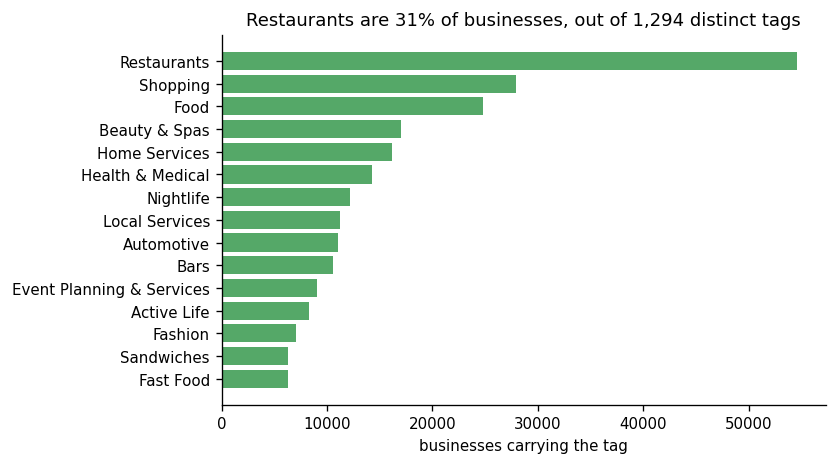

saved /content/drive/My Drive/DS_Project_Portfolio/Yelp-analysis/figures/02_top_categories.png


In [5]:
cats = biz["categories"].str.split(";").explode().str.strip()
R["n_unique_categories"] = int(cats.nunique())
top_cats = cats.value_counts().head(15)
R["top_categories"] = top_cats.to_dict()

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.barh(top_cats.index[::-1], top_cats.values[::-1], color="#55A868")
ax.set_xlabel("businesses carrying the tag")
ax.set_title(f"Restaurants are {R['restaurant_share']:.0%} of businesses, out of {R['n_unique_categories']:,} distinct tags")
show(fig, "02_top_categories.png")

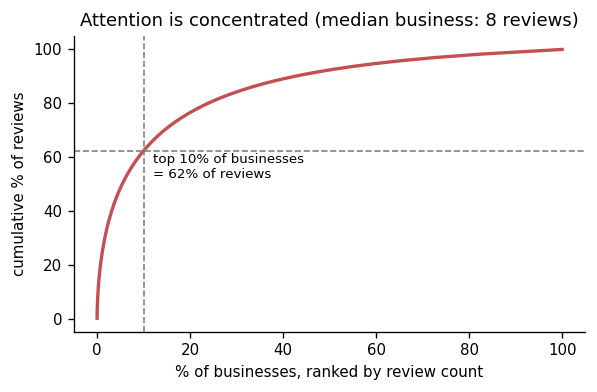

saved /content/drive/My Drive/DS_Project_Portfolio/Yelp-analysis/figures/03_review_concentration.png


In [6]:
rc = biz["review_count"].sort_values(ascending=False).reset_index(drop=True)
cum = rc.cumsum() / rc.sum()
for p in [1, 5, 10, 20]:
    R[f"top{p}pct_biz_share_reviews"] = round(float(cum.iloc[int(len(rc) * p / 100) - 1]), 4)
R["review_count_median"] = int(rc.median())
R["pct_biz_ge_100_reviews"] = round(float((rc >= 100).mean()), 4)

fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.plot(np.arange(1, len(rc) + 1) / len(rc) * 100, cum * 100, color="#C44E52", lw=2)
ax.axvline(10, ls="--", c="grey", lw=1)
ax.axhline(R["top10pct_biz_share_reviews"] * 100, ls="--", c="grey", lw=1)
ax.text(12, R["top10pct_biz_share_reviews"] * 100 - 10,
        f"top 10% of businesses\n= {R['top10pct_biz_share_reviews']:.0%} of reviews", fontsize=8)
ax.set_xlabel("% of businesses, ranked by review count"); ax.set_ylabel("cumulative % of reviews")
ax.set_title(f"Attention is concentrated (median business: {R['review_count_median']} reviews)")
show(fig, "03_review_concentration.png")

### Who closes?
A pattern worth stating carefully, because the obvious reading of it is wrong.

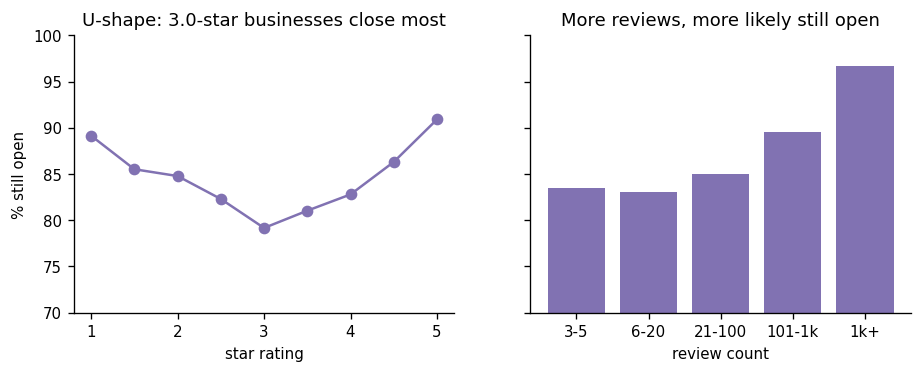

saved /content/drive/My Drive/DS_Project_Portfolio/Yelp-analysis/figures/04_open_rate.png
restaurants 74.0% open vs 88.6% for everything else


In [7]:
open_by_star = biz.groupby("stars")["is_open"].mean()
biz["rc_bucket"] = pd.cut(biz["review_count"], [0, 5, 20, 100, 1000, 10**7],
                          labels=["3-5", "6-20", "21-100", "101-1k", "1k+"])
open_by_vol = biz.groupby("rc_bucket", observed=True)["is_open"].mean()
R["open_rate_by_stars"] = open_by_star.round(4).to_dict()
R["open_rate_by_review_bucket"] = open_by_vol.round(4).to_dict()
R["open_rate_restaurant"] = round(float(biz.loc[biz.is_restaurant, "is_open"].mean()), 4)
R["open_rate_non_restaurant"] = round(float(biz.loc[~biz.is_restaurant, "is_open"].mean()), 4)

fig, axes = plt.subplots(1, 2, figsize=(9, 3), sharey=True)
axes[0].plot(open_by_star.index, open_by_star.values * 100, marker="o", color="#8172B2")
axes[0].set_xlabel("star rating"); axes[0].set_ylabel("% still open")
axes[0].set_title("U-shape: 3.0-star businesses close most")
axes[1].bar(open_by_vol.index.astype(str), open_by_vol.values * 100, color="#8172B2")
axes[1].set_xlabel("review count"); axes[1].set_title("More reviews, more likely still open")
axes[0].set_ylim(70, 100)
show(fig, "04_open_rate.png")

print(f"restaurants {R['open_rate_restaurant']:.1%} open vs {R['open_rate_non_restaurant']:.1%} for everything else")

The U-shape is **not** evidence that bad reviews help. Extreme ratings come from businesses with
very few reviews (one 5-star review makes a 5.0 average), and low-review businesses are
disproportionately new, so they have had less time to close. Review count is the cleaner signal:
83% open at 3-5 reviews rising to 97% at 1,000+. `is_open` is a snapshot with no closure date,
so this is descriptive; a hazard model would need closure timestamps.

---
# Q1. When do customers show up?

Check-ins are the only table recording **behaviour at the venue**; every other table is
commentary written afterwards by people who chose to write. The decision this informs — how many
staff on Friday at 6pm — is normally made on intuition.

The data is pre-aggregated to (business x weekday x hour), so the target is a 7x24 grid.

### 1a. The raw grid is wrong
Aggregating the `hour` column as given puts the weekly peak at **Saturday 01:00-02:00** — for
dentists and hardware stores as much as for bars. A result that fails on a subset where it cannot
possibly hold is a broken result, not an interesting one.

The diagnosis: split the peak hour by state and compare against each metro's timezone.

In [8]:
chk["hr_utc"] = chk["hour"].str.split(":").str[0].astype(int)
chk = chk.merge(biz[["business_id", "state", "is_restaurant"]], on="business_id", how="inner")

raw_peak = chk.groupby(["state", "hr_utc"])["checkins"].sum().unstack(0).idxmax()
R["raw_peak_hour_by_metro"] = {k: int(raw_peak[k]) for k in ["NV", "AZ", "ON", "EDH", "BW"]}
print("peak hour in the raw data, by metro:", R["raw_peak_hour_by_metro"])
print("standard UTC offsets:              {'NV': -8, 'AZ': -7, 'ON': -5, 'EDH': 0, 'BW': +1}")

peak hour in the raw data, by metro: {'NV': 2, 'AZ': 1, 'ON': 23, 'EDH': 18, 'BW': 17}
standard UTC offsets:              {'NV': -8, 'AZ': -7, 'ON': -5, 'EDH': 0, 'BW': +1}


The gaps between metros match their UTC offsets exactly. The timestamps are UTC.

### 1b. Convert to local time
The hour must be shifted **and the weekday must roll over with it**. A 02:00 UTC Saturday
check-in in Las Vegas is Friday 18:00 local. Shifting only the hour would move the entire Friday
evening peak onto Saturday — and Friday 18:00 turns out to be the busiest hour of the week.

In [9]:
UTC_OFF = {"AZ": -7, "NV": -8, "ON": -5, "QC": -5, "NC": -5, "OH": -5, "PA": -5, "SC": -5,
           "WI": -6, "IL": -6,
           "EDH": 0, "MLN": 0, "HLD": 0, "NYK": 0, "ELN": 0, "FIF": 0, "WLN": 0, "BW": 1}

chk["off"] = chk["state"].map(UTC_OFF)
R["pct_checkins_with_tz"] = round(float(chk.loc[chk["off"].notnull(), "checkins"].sum() / chk["checkins"].sum()), 4)
chk = chk[chk["off"].notnull()].copy()

shifted = chk["hr_utc"] + chk["off"].astype(int)
chk["hr"] = shifted % 24                                              # local hour
day_idx = chk["weekday"].map({d: i for i, d in enumerate(DAYS)})
chk["day"] = ((day_idx + np.floor_divide(shifted, 24)) % 7).astype(int).map(dict(enumerate(DAYS)))

local_peak = chk.groupby(["state", "hr"])["checkins"].sum().unstack(0).idxmax()
R["local_peak_hour_by_metro"] = {k: int(local_peak[k]) for k in ["NV", "AZ", "ON", "EDH", "BW"]}
print(f"{R['pct_checkins_with_tz']:.2%} of check-ins mapped to a timezone")
print("peak hour after conversion, by metro:", R["local_peak_hour_by_metro"])

99.99% of check-ins mapped to a timezone
peak hour after conversion, by metro: {'NV': 18, 'AZ': 18, 'ON': 18, 'EDH': 18, 'BW': 18}


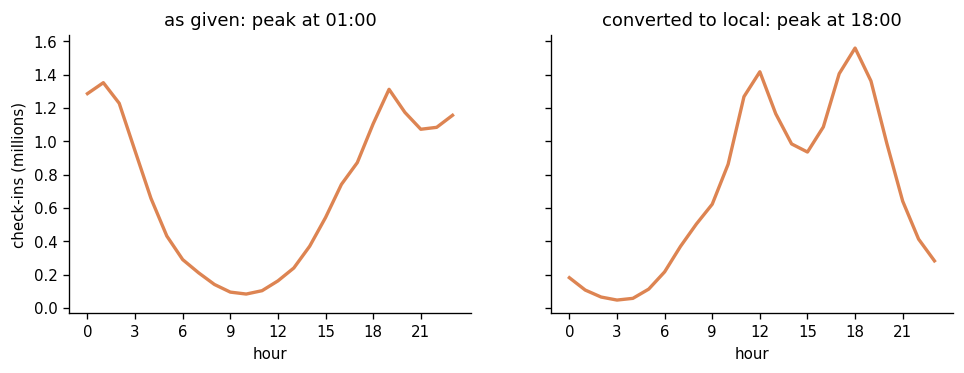

saved /content/drive/My Drive/DS_Project_Portfolio/Yelp-analysis/figures/05_checkin_utc_vs_local.png


In [10]:
utc_grid = chk.groupby(["weekday", "hr_utc"])["checkins"].sum().unstack("weekday")[DAYS]
grid = chk.groupby(["day", "hr"])["checkins"].sum().unstack("day")[DAYS]
grid.to_csv(OUT + "checkins_local_weekday_hour.csv")

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3), sharey=True)
for ax, g, ttl in [(axes[0], utc_grid, "as given: peak at 01:00"),
                   (axes[1], grid, "converted to local: peak at 18:00")]:
    ax.plot(g.index, g.sum(axis=1) / 1e6, color="#DD8452", lw=2)
    ax.set_title(ttl); ax.set_xlabel("hour"); ax.set_xticks(range(0, 24, 3))
axes[0].set_ylabel("check-ins (millions)")
show(fig, "05_checkin_utc_vs_local.png")

All five metros now peak at 18:00. Arizona does not observe daylight saving and lands at 18:00
alongside the rest, which is a useful control: the standard-time-only conversion is good enough
at hourly resolution.

### 1c. The weekly grid

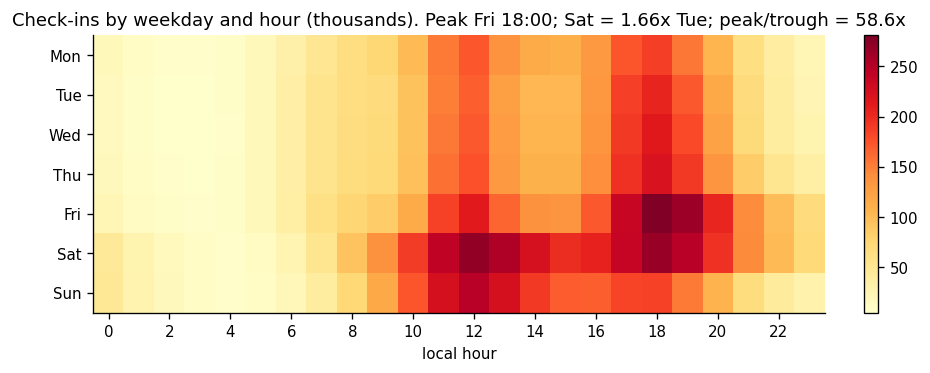

saved /content/drive/My Drive/DS_Project_Portfolio/Yelp-analysis/figures/06_checkin_heatmap_local.png
busiest slots: [('Fri 18:00', 280831), ('Sat 12:00', 269189), ('Sat 18:00', 265887)]
quietest slot: [('Wed 3:00', 4794)]


In [11]:
stacked = grid.stack().sort_values(ascending=False)
R["local_peak_cells"] = [(f"{d} {h}:00", int(v)) for (h, d), v in stacked.head(5).items()]
R["local_trough"] = [(f"{d} {h}:00", int(v)) for (h, d), v in stacked.tail(1).items()]
R["peak_over_trough"] = round(float(stacked.iloc[0] / stacked.iloc[-1]), 1)

by_day = grid.sum(); by_hour = grid.sum(axis=1)
R["share_by_weekday"] = (by_day / by_day.sum()).round(4).to_dict()
R["sat_over_tue"] = round(float(by_day["Sat"] / by_day["Tue"]), 2)
R["share_17_21"] = round(float(by_hour.loc[17:21].sum() / by_hour.sum()), 4)
R["share_11_14"] = round(float(by_hour.loc[11:14].sum() / by_hour.sum()), 4)

fig, ax = plt.subplots(figsize=(8.5, 3))
im = ax.imshow(grid.T.values / 1e3, aspect="auto", cmap="YlOrRd")
ax.set_yticks(range(7)); ax.set_yticklabels(DAYS)
ax.set_xticks(range(0, 24, 2)); ax.set_xlabel("local hour")
ax.set_title(f"Check-ins by weekday and hour (thousands). Peak {R['local_peak_cells'][0][0]}; "
             f"Sat = {R['sat_over_tue']}x Tue; peak/trough = {R['peak_over_trough']}x")
plt.colorbar(im, ax=ax, fraction=0.025)
show(fig, "06_checkin_heatmap_local.png")

print("busiest slots:", R["local_peak_cells"][:3])
print("quietest slot:", R["local_trough"])

### 1d. Restaurants and everything else have different shapes

Restaurants are 31% of businesses but 56% of check-ins, so plotting the two groups in absolute
terms would only restate that restaurants are more numerous. **Each group is normalised by its
own total**, which changes the question from "which group is bigger" to "what does a day look
like for this type of business" — the question a merchant actually has.

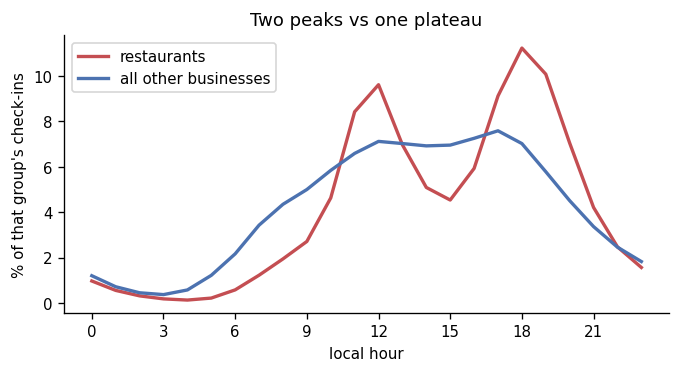

saved /content/drive/My Drive/DS_Project_Portfolio/Yelp-analysis/figures/07_checkin_profile_rest_vs_non.png
restaurants: 16.6% at lunch (12-13h), 28.4% at dinner (18-20h)
non-restaurants: 55.3% in the 10-17h plateau


In [12]:
R["restaurant_share_of_checkins"] = round(float(chk.loc[chk.is_restaurant, "checkins"].sum() / chk["checkins"].sum()), 4)

prof = chk.groupby(["is_restaurant", "hr"])["checkins"].sum().unstack(0)
prof = prof / prof.sum()                       # normalise within group
prof.columns = ["non_restaurant", "restaurant"]
prof.to_csv(OUT + "checkin_hour_profile.csv")

R["rest_share_12_13"] = round(float(prof.loc[12:13, "restaurant"].sum()), 4)
R["rest_share_18_20"] = round(float(prof.loc[18:20, "restaurant"].sum()), 4)
R["nonrest_share_10_17"] = round(float(prof.loc[10:17, "non_restaurant"].sum()), 4)

fig, ax = plt.subplots(figsize=(6.5, 3))
ax.plot(prof.index, prof["restaurant"] * 100, lw=2, color="#C44E52", label="restaurants")
ax.plot(prof.index, prof["non_restaurant"] * 100, lw=2, color="#4C72B0", label="all other businesses")
ax.set_xticks(range(0, 24, 3)); ax.set_xlabel("local hour"); ax.set_ylabel("% of that group's check-ins")
ax.set_title("Two peaks vs one plateau"); ax.legend()
show(fig, "07_checkin_profile_rest_vs_non.png")

print(f"restaurants: {R['rest_share_12_13']:.1%} at lunch (12-13h), {R['rest_share_18_20']:.1%} at dinner (18-20h)")
print(f"non-restaurants: {R['nonrest_share_10_17']:.1%} in the 10-17h plateau")

### 1e. Is a check-in a usable proxy for footfall?
Three checks, because every conclusion above rests on this.
1. **Coverage** — what share of businesses appear at all
2. **Agreement with an independent popularity measure** — correlation with review count. Both are
   heavily right-skewed, so the correlation is taken on logs; on raw values it would be driven by
   a handful of huge venues.
3. **Order of magnitude** — check-ins per review should be sane

In [13]:
per_biz = chk.groupby("business_id")["checkins"].sum()
merged = biz.set_index("business_id").join(per_biz.rename("checkins")).fillna({"checkins": 0})
R["pct_biz_with_checkins"] = round(float((merged["checkins"] > 0).mean()), 4)
R["corr_log_checkins_log_reviews"] = round(float(np.corrcoef(np.log1p(merged["checkins"]),
                                                             np.log1p(merged["review_count"]))[0, 1]), 3)
R["checkins_per_review_median"] = round(float((merged["checkins"] / merged["review_count"]).median()), 2)
print(f"{R['pct_biz_with_checkins']:.0%} of businesses have >=1 check-in | "
      f"log-log corr with review count {R['corr_log_checkins_log_reviews']} | "
      f"median {R['checkins_per_review_median']} check-ins per review")

84% of businesses have >=1 check-in | log-log corr with review count 0.752 | median 1.02 check-ins per review


**Answer.** Friday 18:00 is the busiest hour of the week, Saturday lunch second, with a 59x spread
between the busiest and quietest hour. Restaurants concentrate 16.6% of their traffic in the
lunch hour and 28.4% in the dinner window; every other business type sits on a flat 10:00-17:00
plateau holding 55%. A staffing rule built for one is wrong for the other.

**Limits.** Check-ins measure customers who open the Yelp app at the venue, so restaurants,
nightlife and younger customers are over-represented. The table carries no dates, only
weekday x hour, so nothing here shows seasonality or trend.

---
# Q2. What do unhappy customers write that happy ones don't?

"Improve service" is advice every low-rated restaurant already has, and it is not actionable
because it is not *differential*. The question is reframed: which words appear in low-star text
at a rate they do not appear in high-star text?

**Groups:** restaurants only, rated 4.5+ vs rated 2.0 or below. Restricting to one vertical
removes the confound that a dry cleaner and a bistro are described differently.

**Source:** tips rather than reviews. Median 49 characters, almost no filler, and they cover 64%
of businesses — breadth is what a population-level comparison needs.

In [14]:
STOPWORDS = set("""a about above after again against all am an and any are as at be because been before being below
between both but by can did do does doing don down during each few for from further had has have having he her here
hers herself him himself his how i if in into is it its itself just me more most my myself no nor not now of off on
once only or other our ours ourselves out over own s same she should so some such t than that the their theirs them
themselves then there these they this those through to too under until up very was we were what when where which
while who whom why will with you your yours yourself yourselves get got go went one also really would ve ll re d m
im dont""".split())

def tokens(text):
    return [w for w in re.findall(r"[a-z']+", text.lower()) if w not in STOPWORDS and len(w) > 2]

restaurants = biz[biz.is_restaurant]
hi_ids = set(restaurants.loc[restaurants.stars >= 4.5, "business_id"])
lo_ids = set(restaurants.loc[restaurants.stars <= 2.0, "business_id"])
tips_hi, tips_lo = tip[tip.business_id.isin(hi_ids)], tip[tip.business_id.isin(lo_ids)]

R["n_hi_rest"], R["n_lo_rest"] = len(hi_ids), len(lo_ids)
R["n_tips_hi"], R["n_tips_lo"] = len(tips_hi), len(tips_lo)
R["tip_len_median"] = int(tip["text"].str.len().median())
print(f"{R['n_hi_rest']:,} restaurants at 4.5+ ({R['n_tips_hi']:,} tips) vs "
      f"{R['n_lo_rest']:,} at <=2.0 ({R['n_tips_lo']:,} tips)")

8,008 restaurants at 4.5+ (108,124 tips) vs 4,424 at <=2.0 (14,950 tips)


### 2a. Raw word counts cannot answer this
The most frequent words are the same in both groups, because everyone talks about food, place
and service. Frequency measures how common a word is, not whether it separates the groups.

In [15]:
count_hi = Counter(w for s in tips_hi.text for w in tokens(s))
count_lo = Counter(w for s in tips_lo.text for w in tokens(s))
total_hi, total_lo = sum(count_hi.values()), sum(count_lo.values())
R["tokens_hi"], R["tokens_lo"] = total_hi, total_lo
print("most frequent, 4.5+ :", [w for w, _ in count_hi.most_common(6)])
print("most frequent, <=2.0:", [w for w, _ in count_lo.most_common(6)])

most frequent, 4.5+ : ['great', 'food', 'good', 'place', 'service', 'best']
most frequent, <=2.0: ['food', 'service', 'good', 'place', 'great', "don't"]


### 2b. Log-odds

For every word appearing at least 80 times across both groups:

$$\text{log-odds}(w)=\log\frac{c_{hi}(w)+1}{N_{hi}+1}-\log\frac{c_{lo}(w)+1}{N_{lo}+1}$$

* **Ratio, not counts** — the high-star group has 7x more text, so raw counts only restate group size.
* **Log** — a plain ratio is asymmetric: "4x more common in low-star" is 4.0 while "4x more common
  in high-star" is 0.25, so the same strength of evidence sits 3.0 units from neutral on one side
  and 0.75 on the other. Logs make the two directions symmetric around zero, which is what makes
  the words rankable and plottable on one axis.
* **+1 smoothing** — `tapas` appears 0 times in the low-star group; without smoothing that is
  log(0). Smoothing also pulls thinly-evidenced words toward zero automatically.
* **Frequency floor of 80** — smoothing alone is not enough: a word seen 3 times still scores.
  The floor keeps 1,410 of 31,690 words. Re-running at 50 and 150 does not change the ranked
  extremes.

Not TF-IDF: TF-IDF is a within-document weighting built for retrieval, scoring how well a word
characterises *one document*. Here the unit is a corpus, not a document, and pooling each group
into a single document would collapse IDF to two possible values — zeroing out exactly the words
that appear in both groups, which is where the interesting contrast lives.

{
 "slowest": {
  "count_hi": 7,
  "count_lo": 139,
  "log_odds": -4.79
 },
 "tapas": {
  "count_hi": 216,
  "count_lo": 0,
  "log_odds": 3.45
 },
 "service": {
  "count_hi": 11358,
  "count_lo": 1853,
  "log_odds": -0.12
 },
 "dirty": {
  "count_hi": 106,
  "count_lo": 172,
  "log_odds": -2.41
 },
 "clean": {
  "count_hi": 1031,
  "count_lo": 232,
  "log_odds": -0.44
 }
}


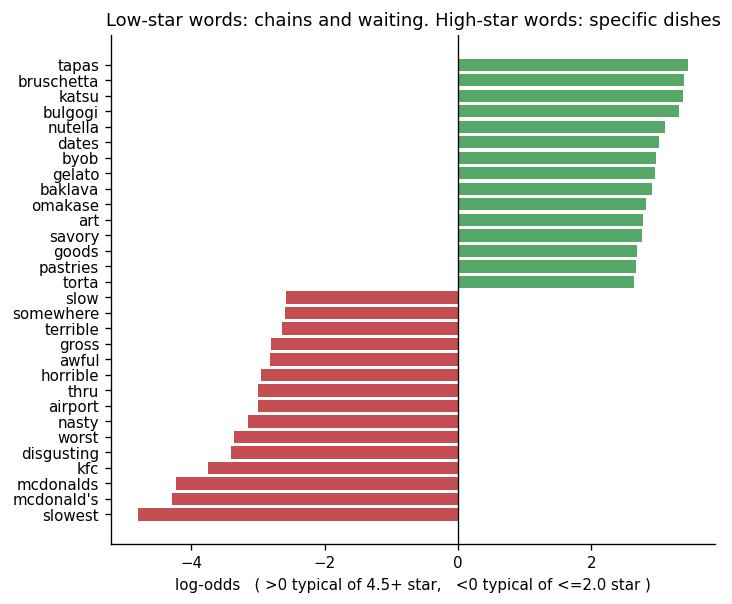

saved /content/drive/My Drive/DS_Project_Portfolio/Yelp-analysis/figures/08_tip_logodds_words.png


In [16]:
MIN_COUNT = 80
rows = []
for w in set(count_hi) | set(count_lo):
    a, c = count_hi[w], count_lo[w]
    if a + c < MIN_COUNT:
        continue
    rows.append((w, a, c, np.log((a + 1) / (total_hi + 1)) - np.log((c + 1) / (total_lo + 1))))

logodds = (pd.DataFrame(rows, columns=["word", "count_hi", "count_lo", "log_odds"])
             .sort_values("log_odds").reset_index(drop=True))
logodds.to_csv(OUT + "tip_word_logodds.csv", index=False)
R["n_words_scored"] = len(logodds)
R["words_low_star_top15"] = logodds.head(15)["word"].tolist()
R["words_high_star_top15"] = logodds.tail(15)["word"].tolist()[::-1]

# worked example for the write-up
R["logodds_examples"] = {w: {"count_hi": int(count_hi[w]), "count_lo": int(count_lo[w]),
                             "log_odds": round(float(np.log((count_hi[w] + 1) / (total_hi + 1))
                                                     - np.log((count_lo[w] + 1) / (total_lo + 1))), 2)}
                         for w in ["slowest", "tapas", "service", "dirty", "clean"]}
print(json.dumps(R["logodds_examples"], indent=1))

extremes = pd.concat([logodds.head(15), logodds.tail(15)])
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.barh(extremes["word"], extremes["log_odds"],
        color=np.where(extremes["log_odds"] > 0, "#55A868", "#C44E52"))
ax.axvline(0, c="k", lw=0.8)
ax.set_xlabel("log-odds   ( >0 typical of 4.5+ star,   <0 typical of <=2.0 star )")
ax.set_title("Low-star words: chains and waiting. High-star words: specific dishes")
show(fig, "08_tip_logodds_words.png")

Two readings. On the surface, high-star tips name **specific dishes** while low-star tips carry
generic disgust and slowness.

Underneath: the low-star vocabulary is full of **chain names** — *mcdonald's, kfc, thru, airport*.
Rating and category are confounded in this data, so a model predicting stars from review text
would partly learn a fast-food detector. Any such model needs category controls. This is a
finding an interpretable method surfaces and a classifier would have hidden.

### 2c. From ranking to magnitude
Log-odds says which words matter but not how big each issue is. A manager needs a unit they can
act on, so the second pass measures **what share of tips mention a theme**, using five keyword
families. `\b` word boundaries matter: without them `wait` matches `waiter`, mixing the waiting
theme into the service theme.

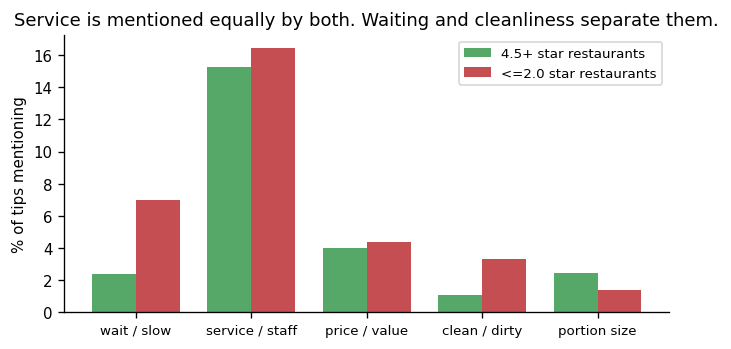

saved /content/drive/My Drive/DS_Project_Portfolio/Yelp-analysis/figures/09_tip_themes.png
                 4.5+ star  <=2.0 star  ratio_lo_over_hi
wait / slow           2.39        6.97              2.91
service / staff      15.26       16.42              1.08
price / value         4.03        4.36              1.08
clean / dirty         1.07        3.30              3.10
portion size          2.42        1.42              0.58


In [17]:
THEMES = {"wait / slow":     r"\b(?:wait|waited|waiting|slow|forever)\b",
          "service / staff": r"\b(?:service|staff|server|waitress|waiter|rude|friendly)\b",
          "price / value":   r"\b(?:price|pricey|expensive|cheap|overpriced|deal|worth)\b",
          "clean / dirty":   r"\b(?:clean|dirty|filthy|gross)\b",
          "portion size":    r"\b(?:portion|portions|huge|small)\b"}

theme = pd.DataFrame({name: {"4.5+ star": tips_hi.text.str.contains(pat, case=False).mean(),
                             "<=2.0 star": tips_lo.text.str.contains(pat, case=False).mean()}
                      for name, pat in THEMES.items()}).T * 100
theme["ratio_lo_over_hi"] = (theme["<=2.0 star"] / theme["4.5+ star"]).round(2)
R["theme_pct"] = theme.round(2).to_dict()

fig, ax = plt.subplots(figsize=(6.5, 3))
x = np.arange(len(theme)); w = 0.38
ax.bar(x - w/2, theme["4.5+ star"], w, color="#55A868", label="4.5+ star restaurants")
ax.bar(x + w/2, theme["<=2.0 star"], w, color="#C44E52", label="<=2.0 star restaurants")
ax.set_xticks(x); ax.set_xticklabels(theme.index, fontsize=8)
ax.set_ylabel("% of tips mentioning"); ax.legend(fontsize=8)
ax.set_title("Service is mentioned equally by both. Waiting and cleanliness separate them.")
show(fig, "09_tip_themes.png")

print(theme.round(2))

**Answer.** Service is a *non-finding*: 15.3% vs 16.4%, no separation. Waiting (2.9x) and
cleanliness (3.1x) are what discriminate; portion size runs the other way, appearing more in
high-star tips as praise. A restaurant with one budget line gets more rating leverage from wait
time and cleanliness than from further service training.

**Limits.** Keyword families miss paraphrase ("we were there for ages"). The clean/dirty family
counts *mentions of the topic*, not complaints — `clean` scores near zero on log-odds because
good restaurants are praised for being clean, while `dirty` is strongly low-star. With 108K and
15K tips, sampling error on these differences is under 0.3pp; self-selection, not sample size, is
the real caveat.

---
# Q3. Is the Elite programme selecting better reviewers?

Content creation is extremely concentrated, which makes the contributor base fragile: losing a
few thousand heavy reviewers moves the product, losing tens of thousands of one-time reviewers
does not. Elite is Yelp's retention lever aimed at that group. Does the badge mark out reviewers
who are more valuable, or just more prolific?

In [18]:
reviews = pd.read_csv(DATA_DIR + "yelp_review.csv",
                      usecols=["review_id", "user_id", "business_id", "stars", "date", "text",
                               "useful", "funny", "cool"])
users = pd.read_csv(DATA_DIR + "yelp_user.csv",
                    usecols=["user_id", "review_count", "yelping_since", "elite", "average_stars", "fans"])

R["n_reviews_raw"] = len(reviews)
R["dup_review_id"] = int(reviews["review_id"].duplicated().sum())
reviews = reviews.drop_duplicates("review_id").dropna(subset=["text"])
reviews["date"] = pd.to_datetime(reviews["date"])
reviews["len"] = reviews["text"].str.len()

R["n_reviews"] = len(reviews)
R["n_reviewers"] = int(reviews["user_id"].nunique())
R["review_date_range"] = [str(reviews["date"].min().date()), str(reviews["date"].max().date())]
R["review_len_median"] = int(reviews["len"].median())
print(f"{R['n_reviews']:,} reviews from {R['n_reviewers']:,} reviewers, "
      f"{R['review_date_range'][0]} to {R['review_date_range'][1]}")

5,261,668 reviews from 1,326,101 reviewers, 2004-07-22 to 2017-12-11


### 3a. How concentrated is contribution?
Counted over **all** 5.26M rows. Sampling reviews and then counting per user would compress the
distribution toward 1: a user with 100 reviews appears with about 100p of them, a user with 1
appears with probability p and still has exactly 1. To estimate a per-user quantity you sample
users, not rows — or, as here, do not sample at all, since one groupby over 5M rows is cheap.

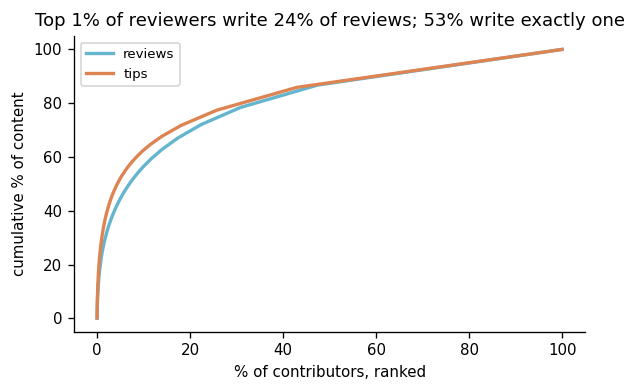

saved /content/drive/My Drive/DS_Project_Portfolio/Yelp-analysis/figures/10_contributor_concentration.png


In [19]:
per_user = reviews.groupby("user_id").size().sort_values(ascending=False).reset_index(drop=True)
cum_u = per_user.cumsum() / per_user.sum()
R["pct_users_one_review"] = round(float((per_user == 1).mean()), 4)
R["pct_users_le_2_reviews"] = round(float((per_user <= 2).mean()), 4)
for p in [1, 5, 10, 20]:
    R[f"top{p}pct_users_share_reviews"] = round(float(cum_u.iloc[int(len(per_user) * p / 100) - 1]), 4)

tip_per_user = tip.groupby("user_id").size().sort_values(ascending=False).reset_index(drop=True)
cum_t = tip_per_user.cumsum() / tip_per_user.sum()
R["n_tip_authors"] = len(tip_per_user)
R["pct_tip_authors_one_tip"] = round(float((tip_per_user == 1).mean()), 4)
R["top1pct_tip_authors_share"] = round(float(cum_t.iloc[int(len(tip_per_user) * 0.01) - 1]), 4)

fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.plot(np.arange(1, len(per_user) + 1) / len(per_user) * 100, cum_u * 100, lw=2, color="#64B5CD", label="reviews")
ax.plot(np.arange(1, len(tip_per_user) + 1) / len(tip_per_user) * 100, cum_t * 100, lw=2, color="#DD8452", label="tips")
ax.set_xlabel("% of contributors, ranked"); ax.set_ylabel("cumulative % of content"); ax.legend(fontsize=8)
ax.set_title(f"Top 1% of reviewers write {R['top1pct_users_share_reviews']:.0%} of reviews; "
             f"{R['pct_users_one_review']:.0%} write exactly one")
show(fig, "10_contributor_concentration.png")

### 3b. Defining "better"
"Better" is not measurable until it is operationalised, and every single measure has an obvious
rebuttal. So four measures are used **that fail for different reasons** — convergence across them
is worth more than one clean-looking number.

| Measure | Captures | How it misleads on its own |
|---|---|---|
| median review length | effort | long is not useful |
| useful votes per review | value as judged by others | confounded with display position and review age |
| share of 1-star and 5-star | calibration | measured is not the same as correct |
| TextBlob polarity | tone | lexicon sentiment is coarse |

The `elite` field is a comma-joined string of years, empty, or the literal `"None"` — all three
forms of "never Elite" must be handled, or `"None"` counts as Elite.

In [20]:
elite_str = users["elite"].astype(str).str.strip()
users["is_elite"] = users["elite"].notnull() & ~elite_str.isin(["None", "", "nan"])
R["pct_users_elite"] = round(float(users["is_elite"].mean()), 4)

reviews = reviews.merge(users[["user_id", "is_elite"]], on="user_id", how="left")
reviews["is_elite"] = reviews["is_elite"].fillna(False).astype(bool)
R["pct_reviews_by_elite"] = round(float(reviews["is_elite"].mean()), 4)

# sanity check: a small group of users writing a large share of reviews is the expected direction
print(f"{R['pct_users_elite']:.1%} of users are Elite and they write {R['pct_reviews_by_elite']:.1%} of reviews")

4.6% of users are Elite and they write 23.8% of reviews


/tmp/ipykernel_8920/3522464788.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  reviews["is_elite"] = reviews["is_elite"].fillna(False).astype(bool)


Length uses the **median**, not the mean: review length is heavily right-skewed, so a mean is
pulled by a few very long reviews and by different amounts in each group.

Useful votes are divided by review count. A total would only restate that Elite users write more;
per-review asks what a single review is worth.

In [21]:
summary = reviews.groupby("is_elite").agg(
    reviews=("review_id", "size"),
    median_length=("len", "median"),
    useful_per_review=("useful", "mean"),
    mean_stars=("stars", "mean"),
    pct_5star=("stars", lambda s: (s == 5).mean()),
    pct_1star=("stars", lambda s: (s == 1).mean()))
R["elite_vs_regular"] = summary.round(3).to_dict()
R["length_ratio"] = round(float(summary.loc[True, "median_length"] / summary.loc[False, "median_length"]), 2)
R["useful_ratio"] = round(float(summary.loc[True, "useful_per_review"] / summary.loc[False, "useful_per_review"]), 2)
R["one_star_ratio"] = round(float(summary.loc[False, "pct_1star"] / summary.loc[True, "pct_1star"]), 2)
print(summary.round(3))

          reviews  median_length  useful_per_review  mean_stars  pct_5star  \
is_elite                                                                     
False     4008616          374.0              1.009       3.710      0.471   
True      1253052          687.0              2.590       3.785      0.291   

          pct_1star  
is_elite             
False         0.169  
True          0.044  


### 3c. Sentiment on a stratified sample
TextBlob scores token by token in Python; 5.26M reviews would take hours. 20,000 per group is
enough: with a polarity standard deviation near 0.24, the standard error of a group mean is
0.24/sqrt(20000) ~ 0.0017, an order of magnitude below the difference being measured. Sampling
20k *per group* rather than 40k overall keeps both groups equally precise — drawing from the
pooled data would leave only ~24% of the sample Elite.

In [22]:
from textblob import TextBlob

sample = pd.concat([reviews[reviews.is_elite].sample(20000, random_state=42),
                    reviews[~reviews.is_elite].sample(20000, random_state=42)])
sample["polarity"] = sample["text"].apply(lambda s: TextBlob(s).sentiment.polarity)
R["polarity_mean"] = sample.groupby("is_elite")["polarity"].mean().round(4).to_dict()
R["polarity_std"] = sample.groupby("is_elite")["polarity"].std().round(4).to_dict()
R["polarity_se"] = {k: round(v / np.sqrt(20000), 5) for k, v in R["polarity_std"].items()}
print(R["polarity_mean"], "| standard errors:", R["polarity_se"])

{False: 0.2437, True: 0.2219} | standard errors: {False: np.float64(0.00175), True: np.float64(0.00117)}


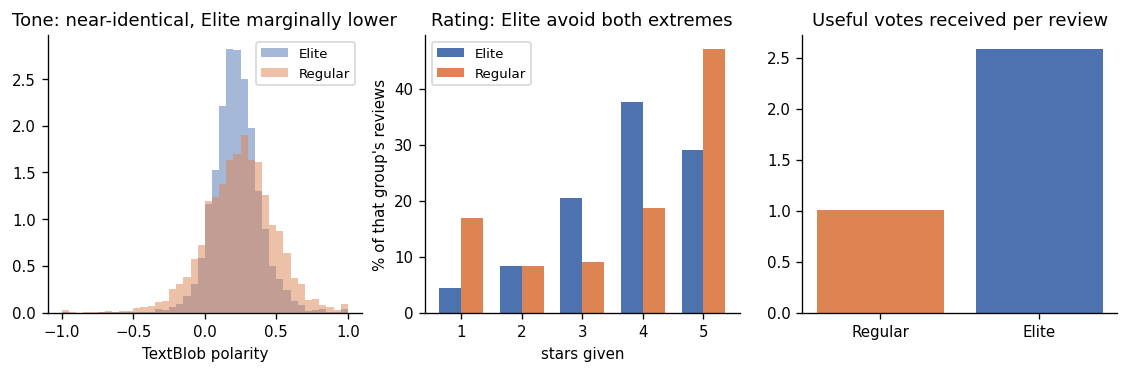

saved /content/drive/My Drive/DS_Project_Portfolio/Yelp-analysis/figures/11_elite_vs_regular.png


In [23]:
star_e = reviews[reviews.is_elite]["stars"].value_counts(normalize=True).sort_index()
star_r = reviews[~reviews.is_elite]["stars"].value_counts(normalize=True).sort_index()

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3))
for e, colour, label in [(True, "#4C72B0", "Elite"), (False, "#DD8452", "Regular")]:
    axes[0].hist(sample.loc[sample.is_elite == e, "polarity"], bins=40, density=True,
                 alpha=0.5, color=colour, label=label)
axes[0].set_xlabel("TextBlob polarity"); axes[0].legend(fontsize=8)
axes[0].set_title("Tone: near-identical, Elite marginally lower")

axes[1].bar(star_e.index - 0.18, star_e.values * 100, 0.36, color="#4C72B0", label="Elite")
axes[1].bar(star_r.index + 0.18, star_r.values * 100, 0.36, color="#DD8452", label="Regular")
axes[1].set_xlabel("stars given"); axes[1].set_ylabel("% of that group's reviews"); axes[1].legend(fontsize=8)
axes[1].set_title("Rating: Elite avoid both extremes")

axes[2].bar(["Regular", "Elite"],
            [summary.loc[False, "useful_per_review"], summary.loc[True, "useful_per_review"]],
            color=["#DD8452", "#4C72B0"])
axes[2].set_title("Useful votes received per review")
show(fig, "11_elite_vs_regular.png")

The means are nearly identical (3.79 vs 3.71) while the **distributions** are not: Elite give far
fewer 5-star and far fewer 1-star ratings. Averaging cancels two opposite shifts, which is why
the distribution has to be looked at directly.

### 3d. Volume over time, and why useful-votes is confounded

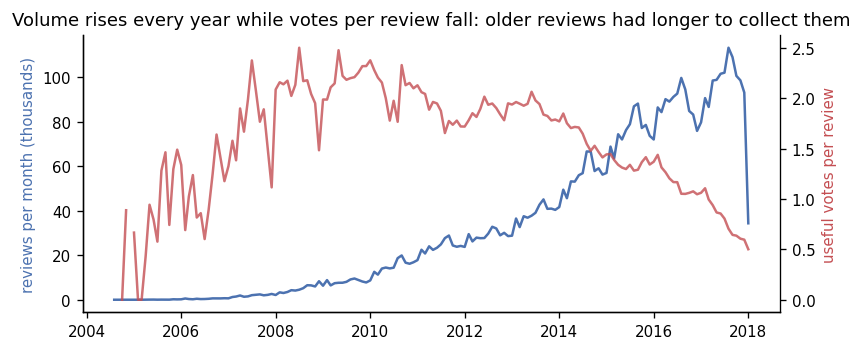

saved /content/drive/My Drive/DS_Project_Portfolio/Yelp-analysis/figures/12_review_volume_over_time.png


In [24]:
monthly = reviews.set_index("date").resample("ME").agg(n=("review_id", "size"), useful_per=("useful", "mean"))
R["reviews_by_year"] = reviews.groupby(reviews["date"].dt.year).size().to_dict()

fig, ax = plt.subplots(figsize=(7.5, 3))
ax.plot(monthly.index, monthly["n"] / 1e3, color="#4C72B0")
ax.set_ylabel("reviews per month (thousands)", color="#4C72B0")
ax2 = ax.twinx(); ax2.plot(monthly.index, monthly["useful_per"], color="#C44E52", alpha=0.8)
ax2.set_ylabel("useful votes per review", color="#C44E52"); ax2.spines["right"].set_visible(True)
ax.set_title("Volume rises every year while votes per review fall: older reviews had longer to collect them")
show(fig, "12_review_volume_over_time.png")

This chart is the reason the 2.6x useful-vote gap cannot be read as quality. Votes accumulate
with age, and Elite users skew older on the platform. Display position is a second confound:
a review ranked higher is seen more and voted on more. Neither can be removed observationally.

The clean test is a ranking experiment — randomise display position, measure useful votes per
review within 30 days of posting. This analysis defines that metric; it does not settle the
question.

**Answer.** Elite users are 4.6% of accounts and write 24% of reviews. Their reviews are 1.8x
longer and collect 2.6x more useful votes, and they are 3.8x less likely to give a one-star
rating. Their mean sentiment is slightly lower. Elite is therefore selecting a *rating
behaviour* — reviewers who use the middle of the scale — not louder enthusiasts. That has a
direct product use: gradated ratings are what fine-grained ranking needs.

**Limits.** Elite is awarded partly *because* someone writes long, well-received reviews, so this
describes who holds the badge, not what the badge causes. "Ever Elite" is used rather than
"Elite at time of writing"; that is the conservative choice, since it puts some pre-Elite reviews
in the Elite bucket and biases against finding a difference.

---
## One merchant, end to end: Gen Korean BBQ House

The business with the most 5-star reviews in the dataset. All three questions, one storefront.

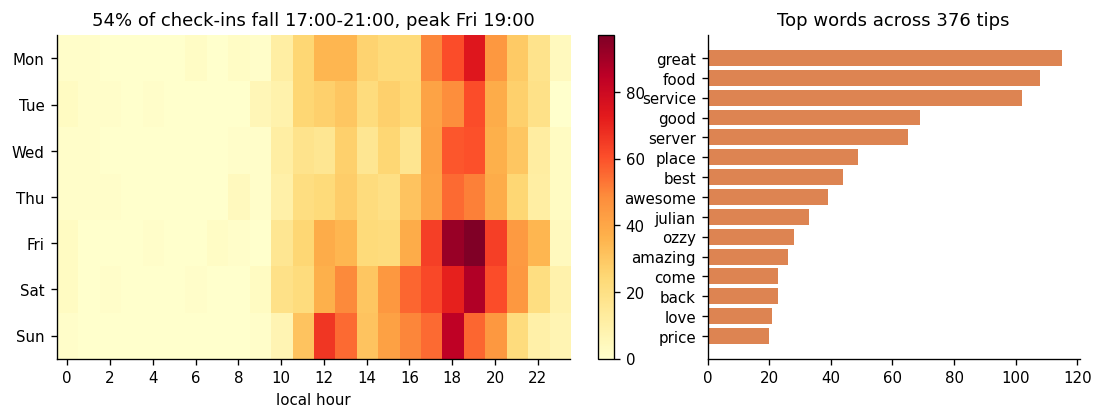

saved /content/drive/My Drive/DS_Project_Portfolio/Yelp-analysis/figures/13_gen_kbbq_timing_and_words.png
[('great', 115), ('food', 108), ('service', 102), ('good', 69), ('server', 65), ('place', 49), ('best', 44), ('awesome', 39), ('julian', 33), ('ozzy', 28)]


In [25]:
GEN = "eLFfWcdb7VkqNyTONksHiQ"
R["gen_meta"] = biz.loc[biz.business_id == GEN,
                        ["name", "city", "state", "stars", "review_count", "is_open"]].iloc[0].to_dict()

gen_grid = (chk[chk.business_id == GEN].groupby(["day", "hr"])["checkins"].sum()
            .unstack("day").reindex(columns=DAYS).reindex(range(24)).fillna(0))
gen_grid.to_csv(OUT + "gen_kbbq_checkins_local.csv")
gen_day = gen_grid.sum()
R["gen_total_checkins"] = int(gen_day.sum())
R["gen_share_by_weekday"] = (gen_day / gen_day.sum()).round(3).to_dict()
R["gen_share_17_21"] = round(float(gen_grid.loc[17:21].sum().sum() / gen_day.sum()), 3)
R["gen_peak"] = f"{gen_grid.stack().idxmax()[1]} {int(gen_grid.stack().idxmax()[0])}:00"

gen_tips = tip[tip.business_id == GEN]
R["gen_n_tips"] = len(gen_tips)
gen_words = Counter(w for s in gen_tips.text for w in tokens(s))
R["gen_top_words"] = gen_words.most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), gridspec_kw={"width_ratios": [1.5, 1]})
im = axes[0].imshow(gen_grid.T.values, aspect="auto", cmap="YlOrRd")
axes[0].set_yticks(range(7)); axes[0].set_yticklabels(DAYS)
axes[0].set_xticks(range(0, 24, 2)); axes[0].set_xlabel("local hour")
axes[0].set_title(f"{R['gen_share_17_21']:.0%} of check-ins fall 17:00-21:00, peak {R['gen_peak']}")
plt.colorbar(im, ax=axes[0], fraction=0.03)
words, counts = zip(*R["gen_top_words"])
axes[1].barh(words[::-1], counts[::-1], color="#DD8452")
axes[1].set_title(f"Top words across {R['gen_n_tips']} tips")
show(fig, "13_gen_kbbq_timing_and_words.png")

print(R["gen_top_words"][:10])

Two server names — Julian and Ozzy — are mentioned more often than *korean* or *bbq*. The most
repeatable asset this restaurant has is named staff, which is a scheduling and retention finding
rather than a menu one.

### What the unhappy reviewers say
Same log-odds machinery as Q2, applied to bigrams within one business: 1-2 star reviews versus
4-5 star reviews. Bigrams rather than single words because complaints here are phrases
("never came", "took forever"); the count floor drops to 8 because one restaurant is a much
smaller corpus.

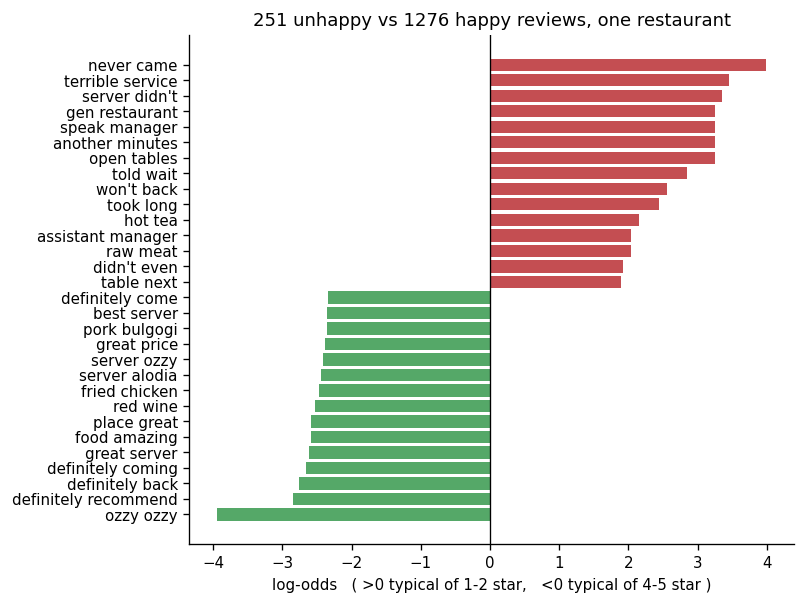

saved /content/drive/My Drive/DS_Project_Portfolio/Yelp-analysis/figures/14_gen_kbbq_complaint_bigrams.png
           bigram  neg_count  pos_count  log_odds_neg_vs_pos
       never came         18          0             3.995693
 terrible service         10          0             3.449149
    server didn't          9          0             3.353839
   gen restaurant          8          0             3.248478
    speak manager          8          0             3.248478
  another minutes          8          0             3.248478
      open tables          8          0             3.248478
        told wait         11          1             2.843013
       won't back          8          1             2.555331
        took long          7          1             2.437548
          hot tea          8          2             2.149866
assistant manager          7          2             2.032083
{'gen_pct_mentioning_wait': {'1-2 star': 0.466, '4-5 star': 0.299}, 'gen_pct_mentioning_server': {'1

In [26]:
gen_reviews = reviews[reviews.business_id == GEN]
R["gen_n_reviews"] = len(gen_reviews)
R["gen_review_stars_dist"] = gen_reviews["stars"].value_counts(normalize=True).sort_index().round(3).to_dict()

def bigram_counts(texts):
    counter = Counter()
    for s in texts:
        tk = tokens(s)
        counter.update(zip(tk, tk[1:]))
    return counter

neg = bigram_counts(gen_reviews.loc[gen_reviews.stars <= 2, "text"])
pos = bigram_counts(gen_reviews.loc[gen_reviews.stars >= 4, "text"])
n_neg, n_pos = sum(neg.values()), sum(pos.values())
R["gen_n_neg_reviews"] = int((gen_reviews.stars <= 2).sum())
R["gen_n_pos_reviews"] = int((gen_reviews.stars >= 4).sum())

rows = [(" ".join(k), neg[k], pos[k],
         np.log((neg[k] + 1) / (n_neg + 1)) - np.log((pos[k] + 1) / (n_pos + 1)))
        for k in set(neg) | set(pos) if neg[k] + pos[k] >= 8]
gen_lo = (pd.DataFrame(rows, columns=["bigram", "neg_count", "pos_count", "log_odds_neg_vs_pos"])
            .sort_values("log_odds_neg_vs_pos", ascending=False).reset_index(drop=True))
gen_lo.to_csv(OUT + "gen_kbbq_bigram_logodds.csv", index=False)
R["gen_neg_bigrams_top15"] = gen_lo.head(15)[["bigram", "neg_count", "pos_count"]].values.tolist()

for kw in ["wait", "server", "manager", "cold"]:
    R[f"gen_pct_mentioning_{kw}"] = {
        "1-2 star": round(float(gen_reviews.loc[gen_reviews.stars <= 2, "text"].str.contains(kw, case=False).mean()), 3),
        "4-5 star": round(float(gen_reviews.loc[gen_reviews.stars >= 4, "text"].str.contains(kw, case=False).mean()), 3)}

extremes = pd.concat([gen_lo.head(15), gen_lo.tail(15)])
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.barh(extremes["bigram"][::-1], extremes["log_odds_neg_vs_pos"][::-1],
        color=np.where(extremes["log_odds_neg_vs_pos"][::-1] > 0, "#C44E52", "#55A868"))
ax.axvline(0, c="k", lw=0.8)
ax.set_xlabel("log-odds   ( >0 typical of 1-2 star,   <0 typical of 4-5 star )")
ax.set_title(f"{R['gen_n_neg_reviews']} unhappy vs {R['gen_n_pos_reviews']} happy reviews, one restaurant")
show(fig, "14_gen_kbbq_complaint_bigrams.png")

print(gen_lo.head(12).to_string(index=False))
print({k: v for k, v in R.items() if k.startswith("gen_pct_mentioning")})

The complaint phrases are almost entirely about **waiting and service response** — *never came*,
*told wait*, *took forever*, *speak manager*, *another server*. 46.6% of 1-2 star reviews mention
waiting versus 29.9% of 4-5 star reviews. That matches the cross-restaurant result in Q2 from a
completely different direction: one business's own reviews, rather than 12,000 businesses' tips.

In [27]:
json.dump(R, open(OUT + "results.json", "w"), indent=2, default=str)
print(f"{len(R)} results written to {OUT}results.json")
print(sorted(os.listdir(FIG)))

93 results written to /content/drive/My Drive/DS_Project_Portfolio/Yelp-analysis/outputs/results.json
['01_star_distribution.png', '02_top_categories.png', '03_review_concentration.png', '04_open_rate.png', '05_checkin_utc_vs_local.png', '06_checkin_heatmap_local.png', '07_checkin_profile_rest_vs_non.png', '08_tip_author_concentration.png', '08_tip_logodds_words.png', '09_tip_logodds_words.png', '09_tip_themes.png', '10_contributor_concentration.png', '10_tip_themes.png', '11_elite_vs_regular.png', '11_gen_kbbq_one_pager.png', '12_review_volume_over_time.png', '13_gen_kbbq_timing_and_words.png', '14_gen_kbbq_complaint_bigrams.png']
